# Langevin Monte Carlo | Unadjusted Langevin Algorithm

A way to sample from a target distribution that requires $\nabla_X \log p(X)$ to be available. The Langevin dynamics drive the random walk towards regions of high probability using gradient flow. The method constructs a Markov chain $q(X_t|X_{t-1}=x_{t-1}) \sim \mathcal{N}(X_t;\mu=x_{t-1} + \tau \nabla_X \log p(X)\vert_{x_{t-1}}, \sigma^2=2\tau)$

This is related to generative models that use the gradient of the data distribution.

References
- https://en.wikipedia.org/wiki/Metropolis-adjusted_Langevin_algorithm
- https://yang-song.github.io/blog/2021/score/


In [1]:
import torch
import torch.distributions as D
import torch.nn.functional as F
import matplotlib.pyplot as plt
from IPython.display import clear_output
from typing import Iterator, Callable
import itertools
import time

In [2]:
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['figure.dpi'] = 100

In [4]:
! pip install git+https://github.com/cheind/diffusion-models.git
# ! pip install -e ..

  Cloning https://github.com/cheind/diffusion-models.git to /private/var/folders/nc/zbqbbkkx08z7v1g3mlf8bdn00000gn/T/pip-req-build-aapsqetw
  Running command git clone --filter=blob:none --quiet https://github.com/cheind/diffusion-models.git /private/var/folders/nc/zbqbbkkx08z7v1g3mlf8bdn00000gn/T/pip-req-build-aapsqetw
  Resolved https://github.com/cheind/diffusion-models.git to commit 5cc43ead49783894d748efa29af0073a0b4178e8
  Preparing metadata (setup.py) ... done
  DEPRECATION: Building 'diffusion-models' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'diffusion-models'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  Created wheel for diffusion-models: filename=diffu

In [5]:
from diffusion import langevin

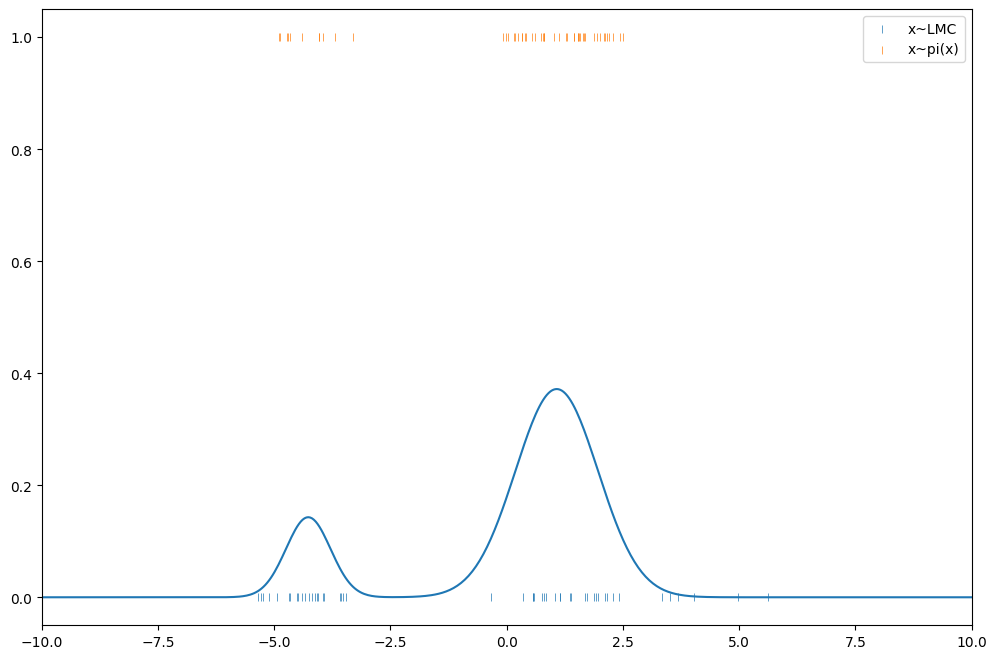

In [15]:
torch.manual_seed(222)

mix = D.Categorical(F.softmax(torch.randn(2,)))
comp = D.Normal(torch.randn(2,)*2, torch.rand(2,))
print(mix.probs, comp.mean, comp.variance)
pi = D.MixtureSameFamily(mix, comp)

xpdf = torch.linspace(-10, 10, 500)
ypdf = torch.exp(pi.log_prob(xpdf))

x0 = torch.rand(50)*20 - 10

def grad_logp_fn(x:torch.Tensor)->torch.Tensor:
  grads = torch.autograd.grad(pi.log_prob(x).sum(), x)
  return grads[0]

g = langevin.iterate_ula(grad_logp_fn, x0, tau=1e-2, n_burnin=100)

for x in itertools.islice(g, 10):
  plt.xlim(-10, 10)
  plt.scatter(x, torch.zeros_like(x), marker='|', linewidths=0.5, label='x~LMC')
  plt.scatter(pi.sample((50,)), torch.ones(50), marker='|', linewidths=0.5, label='x~pi(x)')
  plt.plot(xpdf, ypdf)
  plt.legend(loc='upper right')
  plt.show()  
  time.sleep(0.02)
  clear_output(wait=True)

## Observations
 - if the x is in regions where the $\nabla_x \log p(x)$ is small, nearly no deterministic movement happens. Only the random term would then push x around
 - if your distribution happens to have multiple modalities with valleys of zero score function gradients in between and all your points starts in one mode, chances are slim that you will populate the other modes.
 - If $\tau$ is small, we introduce only small bias but it takes a large number of iterations to explore the support of the target distribution. If $\tau$ is large quickly the support of the target distribution but introduce more bias. Should we start we change $\tau$ over time?

https://github.com/abdulfatir/sampling-methods-numpy/blob/master/Langevin-Monte-Carlo.ipynb

## Sampling from energy models
Consider a density of following form $$p(x)=\frac{1}{Z}q(x),$$ where $Z$ is the partition function given by $\int_r q(r)dr$. Often the partition function is intractable. However, for sampling we don't require it
$$
\begin{align}
\nabla_x \log p(x) &= \nabla_x\log q(x) - \nabla_x \log Z \\
& = \nabla_x\log q(x),
\end{align}
$$ 
since $Z$ does not depend on $x$ (integrated out). Hence, for the purpose of sampling, $Z$ is not required. The example below samples from an energy-model $$p(x)=\frac{1}{Z}e^{-U(x)}.$$ From above we have $\nabla_x \log p(x) = -\nabla_x U(x)$.

tensor([[ 5.1303],
        [ 5.0294],
        [13.9869],
        ...,
        [ 9.4850],
        [ 4.9805],
        [ 4.2230]])
tensor([[ 6.6455],
        [ 4.7745],
        [12.3870],
        ...,
        [10.1418],
        [ 3.5320],
        [ 4.2776]])
tensor([[ 4.0203],
        [ 6.2072],
        [12.2984],
        ...,
        [10.0549],
        [ 3.6605],
        [ 4.2629]])
tensor([[ 2.3004],
        [ 5.8865],
        [11.6039],
        ...,
        [ 9.4794],
        [ 3.7832],
        [ 4.1629]])
tensor([[ 1.4348],
        [ 5.4881],
        [11.0944],
        ...,
        [ 8.7885],
        [ 2.5285],
        [ 4.0363]])
tensor([[2.0463],
        [4.1216],
        [9.7034],
        ...,
        [8.0158],
        [1.9131],
        [3.7544]])
tensor([[0.3053],
        [1.9478],
        [9.4408],
        ...,
        [8.1570],
        [2.4665],
        [3.9200]])
tensor([[1.0553],
        [1.7360],
        [8.0387],
        ...,
        [9.8627],
        [2.4932],
        [3.95

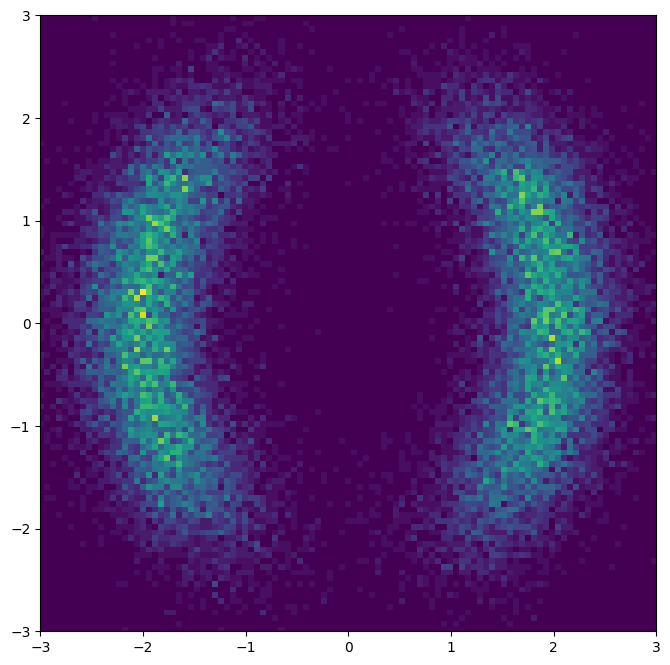

In [ ]:
def u(z):
    # Taken from https://github.com/abdulfatir/sampling-methods-numpy/blob/master/Langevin-Monte-Carlo.ipynb
    z = z.view(-1, 2)
    z1, z2 = z[:, 0], z[:, 1]
    norm = torch.norm(z, p=2, dim=1)
    exp1 = torch.exp(-0.5 * ((z1 - 2) / 0.6) ** 2)
    exp2 = torch.exp(-0.5 * ((z1 + 2) / 0.6) ** 2)
    u = 0.5 * ((norm - 2) / 0.4) ** 2 - torch.log(exp1 + exp2)
    return u


def grad_logp(x:torch.Tensor)->torch.Tensor:
  grads = torch.autograd.grad(-u(x).sum(), x)
  print(grads)
  return grads[0]#/torch.norm(grads[0], p=2, dim=1, keepdim=True)

x0 = torch.randn(30000,2)
samples = langevin.ula(grad_logp, x0, n_steps=1, tau=1e-2, n_burnin=1000).view(-1,2).numpy()

plt.hist2d(samples[:,0], samples[:,1], cmap='viridis', rasterized=False, bins=128)
plt.gca().set_aspect('equal', adjustable='box')
plt.xlim([-3, 3])
plt.ylim([-3, 3])
plt.show()

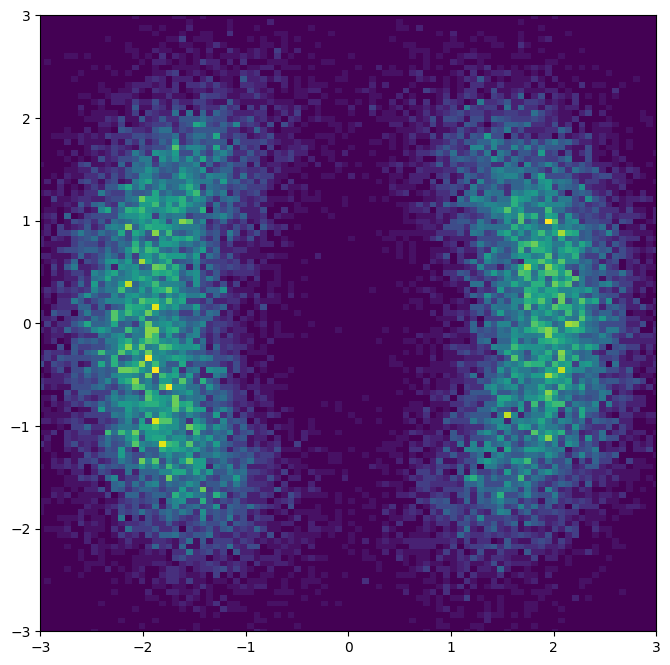

In [8]:
# Same as above, but just one sample bouncing around. Slightly higher tau to allow
# easier transitions between modes
x0 = torch.randn(1,2)
samples = langevin.ula(grad_logp, x0, n_steps=30000, tau=1e-1, n_burnin=1000)# (Steps,Samples,D)
samples = samples.view(-1, 2).numpy()
plt.hist2d(samples[:,0], samples[:,1], cmap='viridis', rasterized=False, bins=128)
plt.gca().set_aspect('equal', adjustable='box')
plt.xlim([-3, 3])
plt.ylim([-3, 3])
plt.show()

## Compound Mixture : Noise distribution

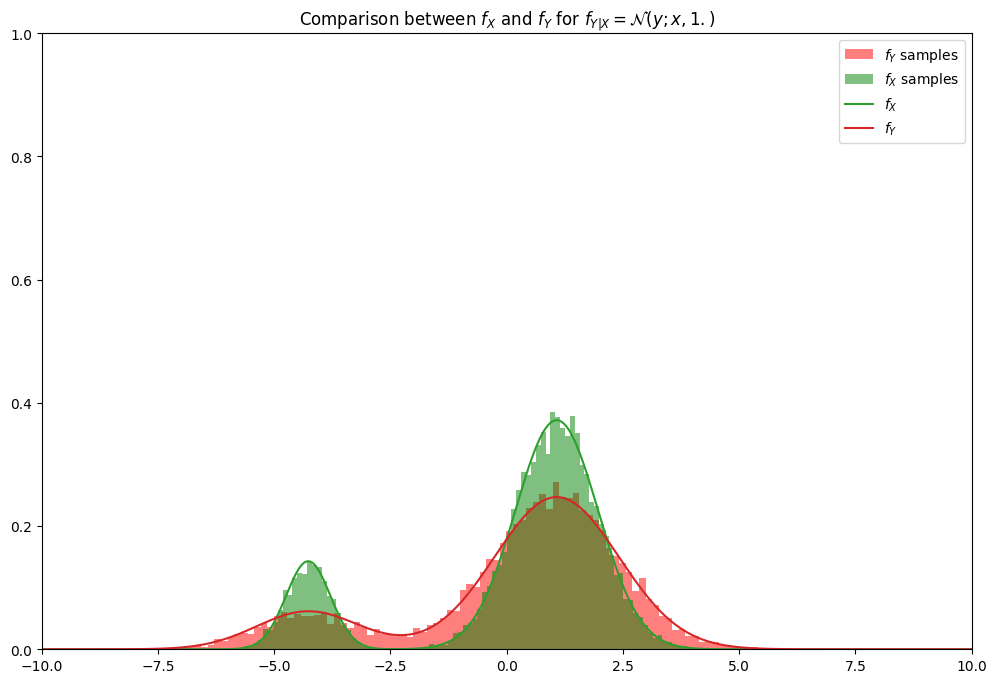

In [9]:
torch.manual_seed(222)

def get_pi(q_scale=0.):
    mix = D.Categorical(torch.tensor([0.1712, 0.8288]))
    comp = D.Normal(torch.tensor([-4.2684,  1.0752]), torch.sqrt(torch.tensor([0.2281, 0.7906]) + q_scale))
    pi = D.MixtureSameFamily(mix, comp)
    return pi

q_scale = 1.0

pi = get_pi()
qpi = get_pi(q_scale)

q = D.Normal(pi.sample((10000,)), scale=q_scale)


xpdf = torch.linspace(-10, 10, 500)
ypdf = torch.exp(pi.log_prob(xpdf))
qpdf = torch.exp(qpi.log_prob(xpdf))

plt.xlim(-10, 10)
plt.ylim(0,1)
plt.hist(q.sample().float().numpy().flatten(), 100, density=True, facecolor='r', alpha=0.5, label= "$f_Y$ samples")
plt.hist(pi.sample((10000,)).float().numpy().flatten(), 100, density=True, facecolor='g', alpha=0.5, label="$f_X$ samples")
plt.plot(xpdf, ypdf, label='$f_X$')
plt.plot(xpdf, qpdf, label='$f_Y$')
plt.legend(loc='upper right')
plt.title('Comparison between $f_X$ and $f_Y$ for $f_{Y|X}=\mathcal{N}(y;x,1.)$')
plt.show()  


